In [138]:
import csv
from pathlib import Path
from decoder_helper import decoded_j2735_from_secured
from pprint import pprint
from collections import defaultdict

def decode_log_csv(filepath: str, n : None|int=None, do_print=False):
    assert Path(filepath).resolve().exists(), f"File {filepath} not found."
    rSig_to_data = defaultdict(list)
    with open(filepath, mode="r", encoding="utf-8") as f:
        reader = csv.reader(f)

        for i, row in enumerate(reader):
            if n is not None and i>n:
                break
            if len(row)<2:
                continue
            ts = row[0]
            packet = row[1].strip()
            
            try:
                wsmp, ieee1609dot2_data, j2735_data = decoded_j2735_from_secured(packet)
                if do_print:
                    print("Packet length: ", len(packet))
                    print("Timestamp:", ts)
                    print("WSMP: ")
                    pprint(wsmp)
                    print("Ieee1609.2 data:")
                    pprint(ieee1609dot2_data)
                    print("J2735 data:")
                    pprint(j2735_data)
                if ieee1609dot2_data is not None:
                    rSig = ieee1609dot2_data["content"]["signedData"]["signature"]["ecdsaNistP256Signature"]["rSig"]["x-only"]
                    if rSig in rSig_to_data:
                        print(f"{rSig} already in the map!")
                    rSig_to_data[rSig].append(
                            {"wsmp":wsmp,
                            "ieee1609dot2":ieee1609dot2_data,
                            "j2735": j2735_data,
                            "timestamp": float(ts)
                            }
                        )
            except Exception as e:
                print("error: ", str(e))
                continue

    return rSig_to_data


rSig_map_outbound = decode_log_csv("logs/packets_outbound.csv",do_print=False)
print(len(rSig_map_outbound))

102


In [139]:
rSig_map_inbound = decode_log_csv("logs/packets_inbound.csv",do_print=False)
print(len(rSig_map_inbound))

Error decoding j2735 data: 'signedData'
error:  'signedData'
Error decoding j2735 data: 'signedData'
error:  'signedData'
fb2c2b0c441549866c946733341a6e4698f243f4da75e36169a0ae65cbf86a0a already in the map!
fb2c2b0c441549866c946733341a6e4698f243f4da75e36169a0ae65cbf86a0a already in the map!
Error decoding j2735 data: 'signedData'
error:  'signedData'
Error decoding j2735 data: 'signedData'
error:  'signedData'
82359dd2d8d1716c909f226f10563dc44e5ff256ebc2ba0553a0c756b841a3c8 already in the map!
Error decoding j2735 data: 'signedData'
error:  'signedData'
Error decoding j2735 data: 'signedData'
error:  'signedData'
Error decoding j2735 data: 'signedData'
error:  'signedData'
Error decoding j2735 data: 'signedData'
error:  'signedData'
6d135db68ae742732f721d6609bddae21a4ef1a8e71e203d0a87e7f7941ad342 already in the map!
df11bd4a7a77afdbc3874381597e20ace0a15380e4a932ca3dffe49d336be47c already in the map!
Error decoding j2735 data: 'signedData'
error:  'signedData'
4d1637313f838714856218b018

In [140]:
import numpy as np

In [146]:
for k, v in rSig_map_inbound.items():
    if len(v)>1:
        print(f"duplicate rSig: {k}")
        # check if all messages are the same
        print(f"all the same message: {np.all( [_v['wsmp']==v[0]['wsmp'] for _v in v] )}")
        for _v in v:
            print(_v)

duplicate rSig: fb2c2b0c441549866c946733341a6e4698f243f4da75e36169a0ae65cbf86a0a
all the same message: True
{'wsmp': {'subtype': {'nullNetworking': {'version': 3}}, 'transport': {'bcMode': {'addrInfo': {'content': 32}}}, 'body': '03810040038081b1001480ad57eb7f674ccf23266e80129ea6dd2908de8202000070000000fd7d87d0007fff00006590a0020214c1c1004b3ffbd0082a42100883ffbf0389e0a1004f3ffc105aed921006e3ffbf0352c3a100683ff6905b561a10036bff6504dcda2100373ff2d04bfffa1007ebff2f03bfffa10082bfeb905bfffa100b3bfebb055fffa1006dbfeb705ffffa1003b3feb5051fffa100673feb7031fffa10035bfeb9033fffa1006fbfeb5045fffafffec80040012000028a159dd74f118034aabec8274a75188080fb2c2b0c441549866c946733341a6e4698f243f4da75e36169a0ae65cbf86a0a1ab260a750174d0ec3076addf9c9ce5df686fab192425309cae5e957437a8ab7'}, 'ieee1609dot2': {'protocolVersion': 3, 'content': {'signedData': {'hashId': 'sha256', 'tbsData': {'payload': {'data': {'protocolVersion': 3, 'content': {'unsecuredData': '001480ad57eb7f674ccf23266e80129ea6dd2908de82020000700

In [135]:
decode_log_csv("logs/packets_inbound.csv",n=2,do_print=True)

Error decoding j2735 data: 'signedData'
Packet length:  46
Timestamp: 1787690595.171216 
WSMP: 
{'body': '03800e3c010107060559756e6578012000',
 'subtype': {'nullNetworking': {'version': 3}},
 'transport': {'bcMode': {'addrInfo': {'extension': {'content': 135}}}}}
Ieee1609.2 data:
{'content': {'unsecuredData': '3c010107060559756e6578012000'},
 'protocolVersion': 3}
J2735 data:
None
error:  'signedData'
Packet length:  554
Timestamp: 1787690595.281246 
WSMP: 
{'body': '03810040038081b1001480ad43e2717548ced8266e80139ea6dd2908de0202000070008000fd7cb7d0007fff00006590a0020214c1c1004c3ffbd0062a06100893ffbf0389dce100503ffc1058ed561006f3ffbf0332bfe100693ff6905955de10037bff6504dcd66100383ff2d049fffa1007fbff2f039fffa10083bfeb905bfffa100b4bfebb053fffa1006ebfeb705dfffa1003c3feb504ffffa100683feb702ffffa10036bfeb9033fffa10070bfeb5045fffafffec80040012000028a159dd2b9fb8034aabec8274a751880801d52145b59439b1ab1aad19eba574143e9ef91d6b6e610c6ed87447e2f77ac76bc9885d39ffae07e8ff75755dd62c42c1aa2e33af0bf09b8ad

{'1d52145b59439b1ab1aad19eba574143e9ef91d6b6e610c6ed87447e2f77ac76': {'wsmp': {'subtype': {'nullNetworking': {'version': 3}},
   'transport': {'bcMode': {'addrInfo': {'content': 32}}},
   'body': '03810040038081b1001480ad43e2717548ced8266e80139ea6dd2908de0202000070008000fd7cb7d0007fff00006590a0020214c1c1004c3ffbd0062a06100893ffbf0389dce100503ffc1058ed561006f3ffbf0332bfe100693ff6905955de10037bff6504dcd66100383ff2d049fffa1007fbff2f039fffa10083bfeb905bfffa100b4bfebb053fffa1006ebfeb705dfffa1003c3feb504ffffa100683feb702ffffa10036bfeb9033fffa10070bfeb5045fffafffec80040012000028a159dd2b9fb8034aabec8274a751880801d52145b59439b1ab1aad19eba574143e9ef91d6b6e610c6ed87447e2f77ac76bc9885d39ffae07e8ff75755dd62c42c1aa2e33af0bf09b8ad4b85ee2815e92f'},
  'ieee1609dot2': {'protocolVersion': 3,
   'content': {'signedData': {'hashId': 'sha256',
     'tbsData': {'payload': {'data': {'protocolVersion': 3,
        'content': {'unsecuredData': '001480ad43e2717548ced8266e80139ea6dd2908de0202000070008000fd7cb7d000

In [ ]:
for k, v_out in rSig_map_outbound.items():
    if k in rSig_map_inbound:
        v_in = rSig_map_inbound[k]
        assert v_out["wsmp"] == v_in["wsmp"]
        assert v_out["ieee1609dot2"] == v_in["ieee1609dot2"]
        assert v_out["j2735"] == v_in["j2735"]
    else:
        print(f"Inbound msg not found for rSig: {k}")

Inbound msg not found for rSig: 6575e86572801f64ecb640d7d5c05f3ae20a2abca243e3391033f8dda2fe4ed2


1787690595.102485
Inbound msg not found for rSig: 6575e86572801f64ecb640d7d5c05f3ae20a2abca243e3391033f8dda2fe4ed2


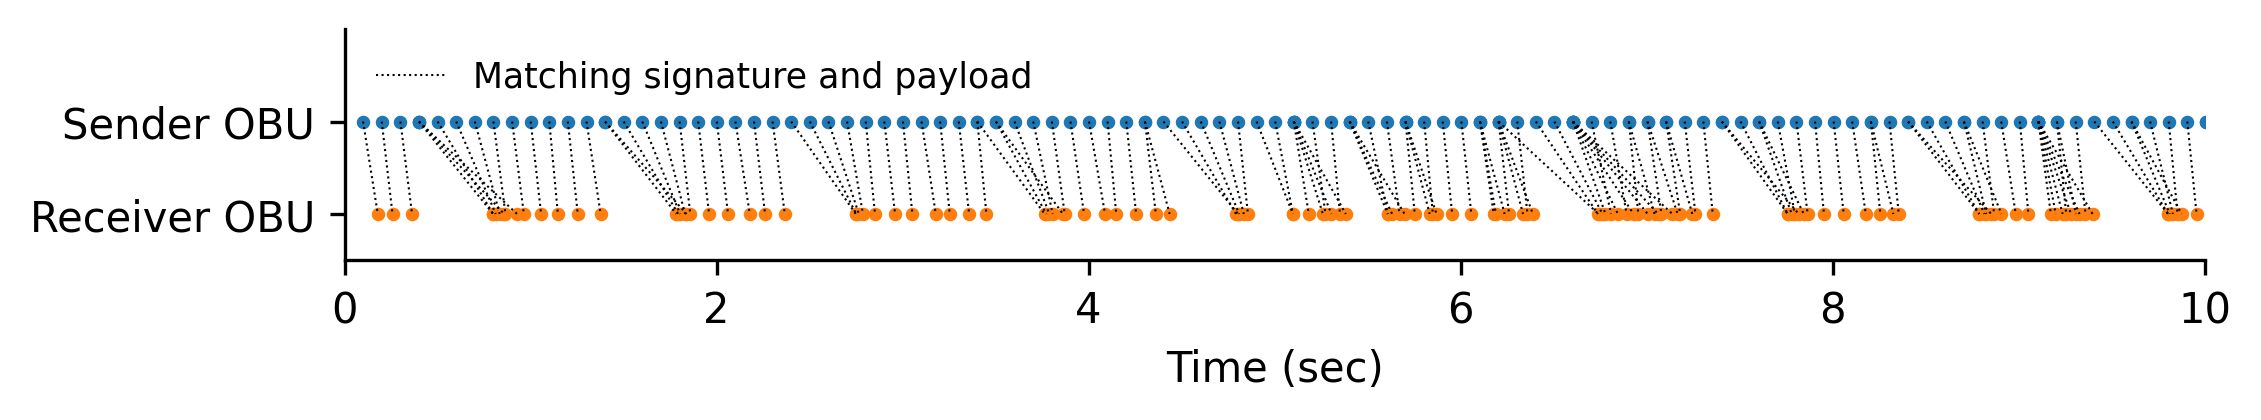

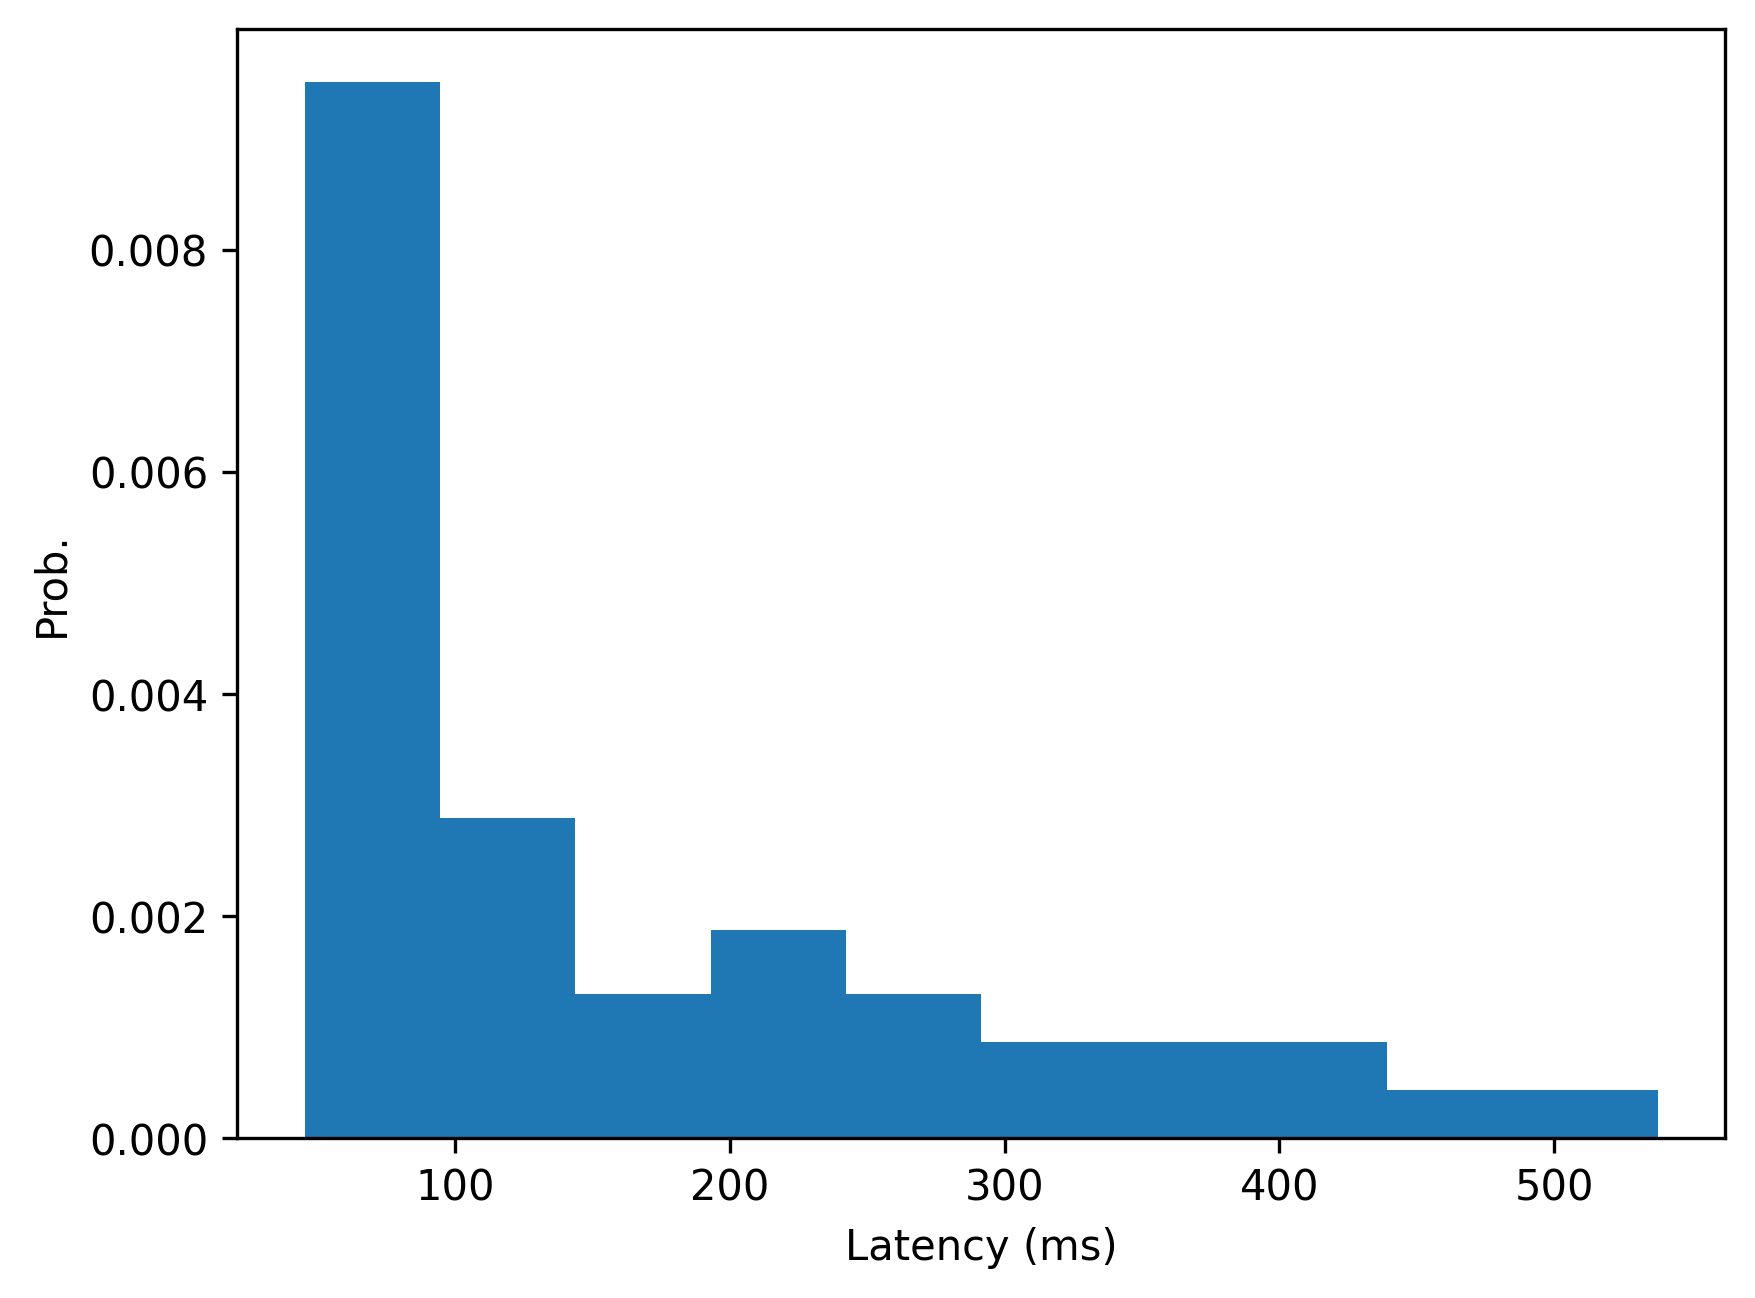

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,1), dpi=300)

t0 = min([v[0]["timestamp"] for v in rSig_map_outbound.values()])
print(t0)

latency = []

ms = 5 # marker size
for k, v_out in rSig_map_outbound.items():
    assert len(v_out)==1
    v_out = v_out[0]
    if k in rSig_map_inbound:
        v_in_lst = rSig_map_inbound[k]
        for v_in in v_in_lst:
            assert v_out["wsmp"] == v_in["wsmp"]
            assert v_out["ieee1609dot2"] == v_in["ieee1609dot2"]
            assert v_out["j2735"] == v_in["j2735"]

            ts_out = v_out["timestamp"] - t0
            ts_in = v_in["timestamp"] - t0

            latency.append((ts_in - ts_out)*1000)

            plt.scatter(ts_out, 1, s=ms, c="C0")
            plt.scatter(ts_in, 0, s=ms, c="C1")
            plt.plot([ts_out, ts_in], [1,0], linestyle=":", color="black", linewidth=0.5)
    else:
        print(f"Inbound msg not found for rSig: {k}")

legend_line, = plt.plot(-1, -1, linestyle=":", color="black", linewidth=0.5, label="Matching signature and payload")
plt.legend(handles=[legend_line], loc="upper left", fontsize="small", edgecolor="none")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim([-0.5, 2])
plt.xlim([0,10])
plt.xlabel("Time (sec)")
ax.set_yticks([0,1], labels=["Receiver OBU", "Sender OBU"])
plt.show()

plt.figure(dpi=300)
plt.hist(latency, bins=10, density=True)
plt.xlabel("Latency (ms)")
plt.ylabel("Prob.")
plt.show()
